## D2D example: CLD on Sleep and Depressive symptoms
In this example, we  implement a system dynamics model (SDM) analysis of a causal loop diagram (CLD) published as an example in the Education Corner article by Uleman et al (2024) doi: 10.1093/ije/dyae091. This CLD focuses on the feedback loops between sleep and depressive symptoms in young adults.

In Kumu, the diagram looks as follows:

<img src="Sleep CLD.jpg" alt="drawing" width="500"/>

To analyze this CLD, we will first imports the settings and the Kumu file. We will then run the simulations with what-if scenarios, assess the intervention effects, conduct the feedback loop analysis, and perform sensitivity analysis over the model parameters.

In [ ]:
import os
from systemdynamics.cld import Extract
from systemdynamics.sdm import SDM
from systemdynamics.plots import plot_simulated_intervention_ranking

current_path = os.getcwd()  # Select current path
file_name = "Sleep"  # Specify the relevant name of the CLD Excel file
file_path = os.path.join(current_path, f"{file_name}.xlsx")

extract = Extract(file_path)  # Load the relevant Kumu file extraction module
s = extract.extract_settings()  # Extract the settings using the Kumu Excel file

# Set simulation settings
s.seed = 1912884
s.N = 100  # Number of simulations
s.t_end = 12  # Timeframe of the simulation
s.time_unit = "Months"  # Base unit of time (time unit of t_end and dt)
s.prior = "uniform"  # "uniform" or "halfnormal"
s.parameter_value = 0.1 #.5  # Max range for uniform, SD for halfnormal

sdm = SDM(s)  # Load the module for formulating and simulating the SDM


Variables of interest: ['Sleep problems', 'Depressive symptoms']
with 8 intervention variables

20 feedback loops of maximum length 5
All loops have at least one stock
1 (5.0%) of these loops are balancing loops
The max length of loops checked is smaller than the number of stocks and auxiliaries; there may be more loops in the CLD



Given these settings, we can now run simulations from the SDM-converted CLD.

In [9]:
df_sol, param_samples, eig_val_vec = sdm.run_simulations()  # Run the simulated interventions
intervention_effects_per_voi = sdm.get_intervention_effects()  # Get the intervention effects

100%|██████████| 100/100 [00:50<00:00,  2.00it/s]


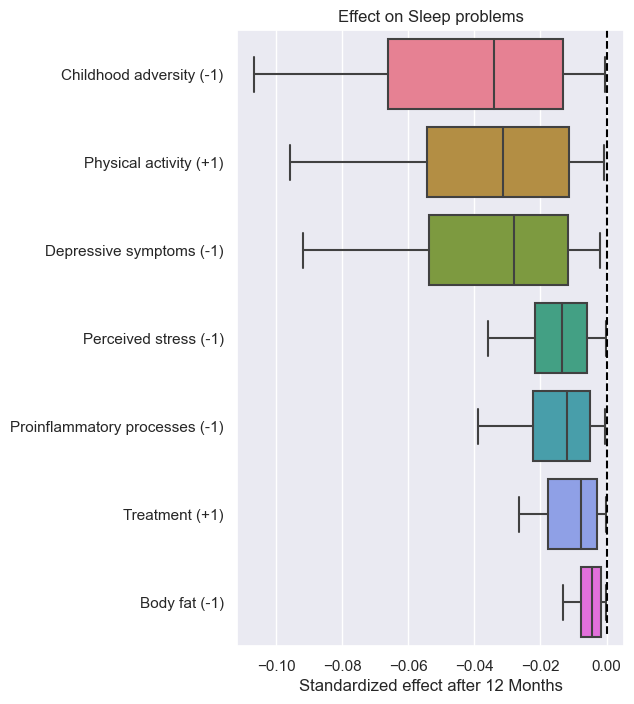

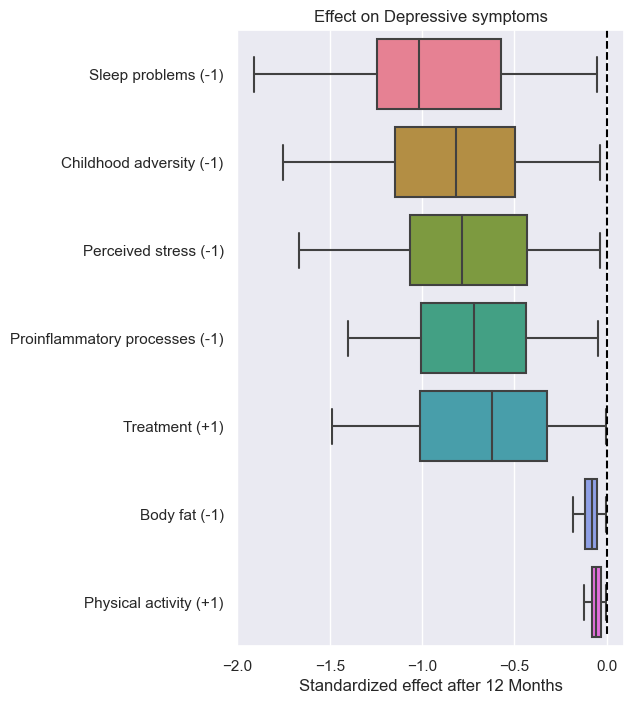

In [10]:
for voi in s.variable_of_interest:
    plot_simulated_intervention_ranking(s, intervention_effects_per_voi[voi],
                                        voi, top_plot=None, order=None);  # Plot the simulated interventions ranking

In [11]:
for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    sdm.compare_interventions_table(intervention_effects_per_voi[voi])  # Print the table of the simulated interventions
    print("")


---- Variable of Interest:  Sleep_problems

Comparison Table (Percentage Greater & Cliff’s Delta):
+---------------------------+---------------------------+-------------+-----------------+
| Intervention A            | Intervention B            |   % Greater |   Cliff's Delta |
+===========================+===========================+=============+=================+
| Sleep_problems            | Childhood_adversity       |          83 |            0.66 |
+---------------------------+---------------------------+-------------+-----------------+
| Sleep_problems            | Physical_activity         |          87 |            0.74 |
+---------------------------+---------------------------+-------------+-----------------+
| Sleep_problems            | Depressive_symptoms       |          91 |            0.82 |
+---------------------------+---------------------------+-------------+-----------------+
| Sleep_problems            | Perceived_stress          |          99 |            0.98 |
+

## Sensitivity analysis

In [13]:
## Estimate spearman correlation for the model parameters, either for one intervention variable (int_var) or for all
cut_off_SA_importance = 0.1 #0.05
int_var = None  # If None, the simulations of all intervention will be used

for voi in s.variable_of_interest:
    print("---- Variable of Interest: ", voi)
    outcome_var = voi  # If None, all variables will be used to assess change in the model
    SA_results, df_SA = sdm.run_SA(outcome_var, int_var, cut_off_SA_importance)
    print("")

---- Variable of Interest:  Sleep_problems
+-------------------------------------------+----------------------+---------+
|                 Variable                  | Spearman correlation | p-value |
+-------------------------------------------+----------------------+---------+
|     Perceived_stress->Sleep_problems      |         0.34         |   0.0   |
|         Body_fat->Sleep_problems          |         0.19         |   0.0   |
| Proinflammatory_processes->Sleep_problems |         0.18         |   0.0   |
|   Depressive_symptoms->Perceived_stress   |         0.15         |   0.0   |
|      Treatment->Depressive_symptoms       |         0.13         |   0.0   |
|   Childhood_adversity->Perceived_stress   |         0.11         |   0.0   |
| Childhood_adversity->Depressive_symptoms  |         0.1          |   0.0   |
+-------------------------------------------+----------------------+---------+

---- Variable of Interest:  Depressive_symptoms
+--------------------------------------

## Stability analysis

System was stable in 0 out of 10 simulations


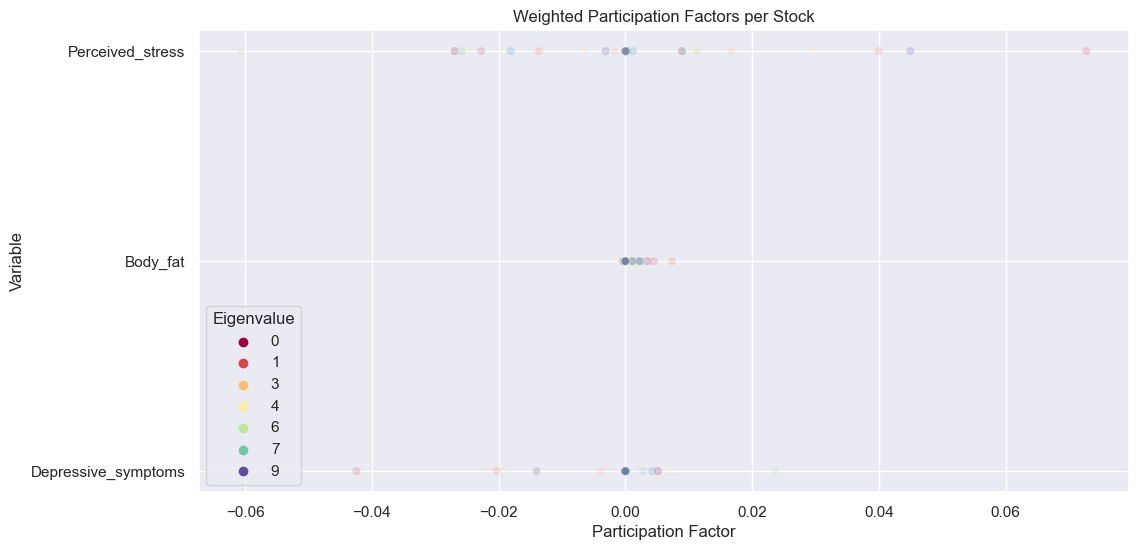

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

stable = 0
weighted_participation_factors = {v: [] for v in s.stocks_and_constants}

for i in range(s.N):
    eigenvals = eig_val_vec["Eigenvalues"][i]
    eigenvecs = eig_val_vec["Eigenvectors"][i]

    # Compute stability margin
    stability_margin = -np.max(np.real(eigenvals))
    if stability_margin > 0:
        stable += 1

    # Compute participation factors
    right_eigenvecs = eigenvecs
    left_eigenvecs = np.linalg.inv(eigenvecs).T
    P_unnorm = np.abs(right_eigenvecs * left_eigenvecs.T)

    if np.isnan(P_unnorm).any():
        raise ValueError("NaNs in unnormalized participation matrix")
    else:
        row_sums = P_unnorm.sum(axis=1, keepdims=True)
        with np.errstate(divide='ignore', invalid='ignore'):
            P = (P_unnorm / row_sums)  # Normalize so rows sum to 1
        P = np.nan_to_num(P, nan=0.0)  # Fill NaN values with zero

    # Create a DataFrame for better readability
    participation_df = pd.DataFrame(
        P, 
        columns=s.stocks_and_constants,
        index=[i for eigenval in eigenvals] #[f"λ={eigval:.4f}" for eigval in eigenvals]
    )
    #participation_df.index.name = "Eigenvalue"
    participation_df['Real_part'] = np.real(eigenvals)
    participation_df.sort_values('Real_part', ascending=False, inplace=True)
    for col in [x for x in participation_df.columns 
                                 if x != "Real_part"]:
        participation_df.loc[:, col] = participation_df.loc[:, col] * participation_df.loc[:, "Real_part"]
        
    # Store all participation factors without summing
    for eigval, row in participation_df.iterrows():
        for var in s.stocks_and_constants:
            weighted_participation_factors[var].append((eigval, row[var]))

print("System was stable in", stable, "out of", s.N, "simulations")

# Convert dictionary to long-form DataFrame for plotting
df_long = pd.DataFrame([
    {"Eigenvalue": eigval, "Variable": var, "Participation Factor": value}
    for var, values in weighted_participation_factors.items()
    for eigval, value in values
])
#df_long.reset_index(drop=True, inplace=True)
#df_long["Index"] = df_long.index

# Only stocks
df_long = df_long.loc[df_long["Variable"].isin(s.stocks), :]

# Order variables by median participation factor
median_participation = df_long.groupby('Variable')['Participation Factor'].median().sort_values(ascending=False)
ordered_variables = median_participation.index

# Create a categorical type with the ordered variables
df_long['Variable'] = pd.Categorical(df_long['Variable'], categories=ordered_variables, ordered=True)

# Scatter Plot of Weighted Participation Values vs. Weighted Participation Factors
plt.figure(figsize=(12, 6))
#sns.boxplot(data=df_long, x="Participation Factor", y="Variable",
#            orient='h', fliersize=0, color='lightgrey')
sns.scatterplot(data=df_long, x="Participation Factor",
                y="Variable", hue="Eigenvalue", palette="Spectral", alpha=0.2)
plt.title("Weighted Participation Factors per Stock") #Box and Scatter Plot of
plt.xlabel("Participation Factor")
plt.show()